# Fase 1 - Exploración de datos
Lo primero que se realizará es la exploración de los datos con ayuda de Colab para el pr-análisis del estado de los datos

In [ ]:
import pandas as pd

df = pd.read_csv("/content/healthcare_dataset.csv")
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


Revisamos las caracteristicas de los valores asi como el total de registros     

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

## Valores  nulos, blancos

Lo primero que revisamos es:


*  **Valores Nulos**: aunque la funcion .info() nos menciona que no, podemos revisarlo por nuestra cuenta para una doble verificación
*  **Valores blancos**: revisar si los datos tienen valores completos pero que pueden ser "basura" ya que solo esta completado para no tener nulos
*   **Valores duplicados**: revisar si existen valores duplicados entre la combinacion de todas las variables

In [ ]:
# Conteo de valores nulos (NaN)
null_count = df.isnull().sum()

# Conteo de valores en blanco (strings vacíos o solo espacios)
blank_count = (df.astype(str).apply(lambda x: x.str.strip()) == "").sum()

# 3. Porcentaje de datos faltantes
missing_percent = (null_count / len(df)) * 100

df_diagnosis = pd.DataFrame({
    'Tipo de Dato': df.dtypes,
    'Nulos (NaN)': null_count,
    'Blancos (" ")': blank_count,
    '% Faltante Total': missing_percent
})

print("--- Diagnóstico de Calidad de Datos ---")
print(df_diagnosis)

# Filas duplicadas
print(f"\nTotal de filas duplicadas: {df.duplicated().sum()}")

--- Diagnóstico de Calidad de Datos ---
                   Tipo de Dato  Nulos (NaN)  Blancos (" ")  % Faltante Total
Name                     object            0              0               0.0
Age                       int64            0              0               0.0
Gender                   object            0              0               0.0
Blood Type               object            0              0               0.0
Medical Condition        object            0              0               0.0
Date of Admission        object            0              0               0.0
Doctor                   object            0              0               0.0
Hospital                 object            0              0               0.0
Insurance Provider       object            0              0               0.0
Billing Amount          float64            0              0               0.0
Room Number               int64            0              0               0.0
Admission Type          

## Valores duplicados

Observamos que no se tiene valores tanto nulos como ben blanco pero si se tiene valores duplicados por lo que revisaremos si esos valores son en realidad duplciados y de que tipo son

In [ ]:
# Filtramos el dataframe para mostrar SOLO las filas que tienen duplicados
df_repetidos = df[df.duplicated(keep=False)]

# Ordenamos por todas las columnas para que las filas idénticas aparezcan juntas
df_repetidos_ordenados = df_repetidos.sort_values(by=list(df.columns))

# Mostramos los primeros 10 registros de este grupo de duplicados
print("--- Visualización de registros duplicados (Filas idénticas juntas) ---")
if not df_repetidos_ordenados.empty:
    print(df_repetidos_ordenados.head(10))
else:
    print("No se encontraron filas duplicadas exactas en el dataset.")

--- Visualización de registros duplicados (Filas idénticas juntas) ---
                Name  Age  Gender Blood Type Medical Condition  \
42407  ABIgaIL YOung   41  Female         O+      Hypertension   
54285  ABIgaIL YOung   41  Female         O+      Hypertension   
26025  ALIcia taYLoR   78    Male         O+            Asthma   
53104  ALIcia taYLoR   78    Male         O+            Asthma   
42323      AMy GREEN   79  Female         B+           Obesity   
50151      AMy GREEN   79  Female         B+           Obesity   
21675  ANDREA HansEN   61    Male         O+            Cancer   
51695  ANDREA HansEN   61    Male         O+            Cancer   
36207  ANDrEA fREnCH   73    Male         A-         Arthritis   
51916  ANDrEA fREnCH   73    Male         A-         Arthritis   

      Date of Admission         Doctor               Hospital  \
42407        2022-12-15  Edward Kramer         Moore-Mcdaniel   
54285        2022-12-15  Edward Kramer         Moore-Mcdaniel   
26025  

Con esto nos damos cuenta de que son por tal cual por valores duplicadosen el registro, asi que lo que sigue ahora es saber si son solo valores que se insertaron 2 veces o mas, por lo que se ve cuanto es el conteo de duplicados por cada valor, teniendo el resumen para saber las veces que se repite

In [ ]:
# Contamos cuántas veces aparece cada combinación de filas
frecuencia_duplicados = df.groupby(df.columns.tolist()).size().reset_index(name='cantidad')

# Filtramos para quedarnos solo con los que aparecen más de 1 vez
solo_duplicados = frecuencia_duplicados[frecuencia_duplicados['cantidad'] > 1]

# Ordenamos de mayor a menor para ver los "peores" casos primero
solo_duplicados = solo_duplicados.sort_values(by='cantidad', ascending=False)

print("--- Top 10 de registros más repetidos ---")
print(solo_duplicados.head(10))

# Resumen de las repeticiones
print("\n--- Distribución de las repeticiones ---")
print(solo_duplicados['cantidad'].value_counts().sort_index().rename_axis('Veces que se repite').reset_index(name='Cantidad de grupos'))

--- Top 10 de registros más repetidos ---
                Name  Age  Gender Blood Type Medical Condition  \
54919   zaCHAry balL   85  Female         B-          Diabetes   
50     ABIgaIL YOung   41  Female         O+      Hypertension   
195    ALIcia taYLoR   78    Male         O+            Asthma   
563        AMy GREEN   79  Female         B+           Obesity   
611    ANDREA HansEN   61    Male         O+            Cancer   
645    ANDrEA fREnCH   73    Male         A-         Arthritis   
53900      tom SmITH   37    Male        AB-          Diabetes   
53599   thOmAS pereZ   22  Female         B+      Hypertension   
53405    taNYa DAVIs   82  Female         A-      Hypertension   
53356   tYler BUrton   69    Male        AB-         Arthritis   

      Date of Admission          Doctor                    Hospital  \
54919        2020-04-25  Matthew Conley  and Morgan Jones, Matthews   
50           2022-12-15   Edward Kramer              Moore-Mcdaniel   
195          2022-

Al saber que solo se tiene 2 valores duplicadosen un total de 534, lo que se presencio al inicio, son filas duplicadas 2 veces por lo que se arregla eliminando la duplicada

Algo que resaltar en esta parte es que la varibale name tiene datos con letras mayusculas y minusculas mezcladas, por lo que en la limpieza de los datos se consideraria dejar solo la primera en mayuscula y las demas en minuscula.

## Valores unicos

In [ ]:
print("--- Valores únicos por columna ---")
print(df.nunique())

--- Valores únicos por columna ---
Name                  49992
Age                      77
Gender                    2
Blood Type                8
Medical Condition         6
Date of Admission      1827
Doctor                40341
Hospital              39876
Insurance Provider        5
Billing Amount        50000
Room Number             400
Admission Type            3
Discharge Date         1856
Medication                5
Test Results              3
dtype: int64


Revisamos los valores unicos en cada una de las columnas, para ver si hay datos sucios, ya que claro mencionamos que no hay nulos y blancos pero no necesariamente significa que sea valida esa data

In [ ]:
print("--- Exploración de Valores Únicos (Orden Ascendente) ---\n")

for columna in df.columns:
    # Obtener valores únicos, quitar nulos y convertir a lista de Python pura
    unique_values = df[columna].unique().tolist()
    total_unicos = len(unique_values)

    # Ordenar de forma ascendente estándar
    valores_ordenados = sorted(unique_values)

    print(f"Columna: '{columna}' | Tipo: {df[columna].dtype} | Únicos: {total_unicos}")

    # Mostrar la muestra de los 20 primeros
    if total_unicos > 20:
        print(f"Muestra de los 20 primeros:")
        print(valores_ordenados[:20])
    else:
        print(f"Todos los valores:")
        print(valores_ordenados)

    print("-" * 50)

--- Exploración de Valores Únicos (Orden Ascendente) ---

Columna: 'name' | Tipo: object | Únicos: 49992
Muestra de los 20 primeros:
['AARON DuncAn', 'AARON HicKS', 'AARON bAldWIN Jr.', 'AARON hAWkIns', 'AAROn HaRt', 'AAROn wiLsON', 'AARoN FOSTer', 'AARoN HOPkINs', 'AARoN grEEnE', 'AARon OnEal', 'AARon SmIth', 'AARon goOdwIn', 'AARon poPe', 'AARon smITh', 'AArON BeNtlEy', 'AArON GOoDmAN', 'AArON ROdRIgueZ', 'AArON RiChaRDsON', 'AArON rOmEro', 'AArON sTrICkLanD']
--------------------------------------------------
Columna: 'age' | Tipo: int64 | Únicos: 77
Muestra de los 20 primeros:
[13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
--------------------------------------------------
Columna: 'gender' | Tipo: object | Únicos: 2
Todos los valores:
['Female', 'Male']
--------------------------------------------------
Columna: 'blood_type' | Tipo: object | Únicos: 8
Todos los valores:
['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']
---------------------------

## Valores Atipicos

Revisamos los valores apiticos para cada columna, para lo que ellos nos resulta mas facil observar estos valore sen histogramas, para ver la dispersion de los datos

Primero transformamos los datos categoricos a valores numericos para que sea posible realizar las graficas

In [ ]:
# Identificar columnas categóricas (las que son tipo 'object')
categoricas = df.select_dtypes(include=['object']).columns

# Creamos un nuevo DataFrame para no arruinar el original
df_numerico = df.copy()

for col in categoricas:
    df_numerico[col] = df_numerico[col].astype('category').cat.codes

print(df_numerico.head())

    name  age  gender  blood_type  medical_condition  date_of_admission  \
0   3068   30       1           5                  2               1729   
1  15211   62       1           0                  5                104   
2   6476   76       0           1                  5               1233   
3  26935   28       0           6                  3                560   
4  26241   43       0           2                  2               1230   

   doctor  hospital  insurance_provider  billing_amount  room_number  \
0   26612     29933                   1    18856.281306          328   
1   33648     16012                   3    33643.327287          265   
2   37828      5473                   0    27955.096079          205   
3   22511     12317                   3    37909.782410          450   
4   21259     33598                   0    14238.317814          458   

   admission_type  discharge_date  medication  test_results  
0               2            1730           3         

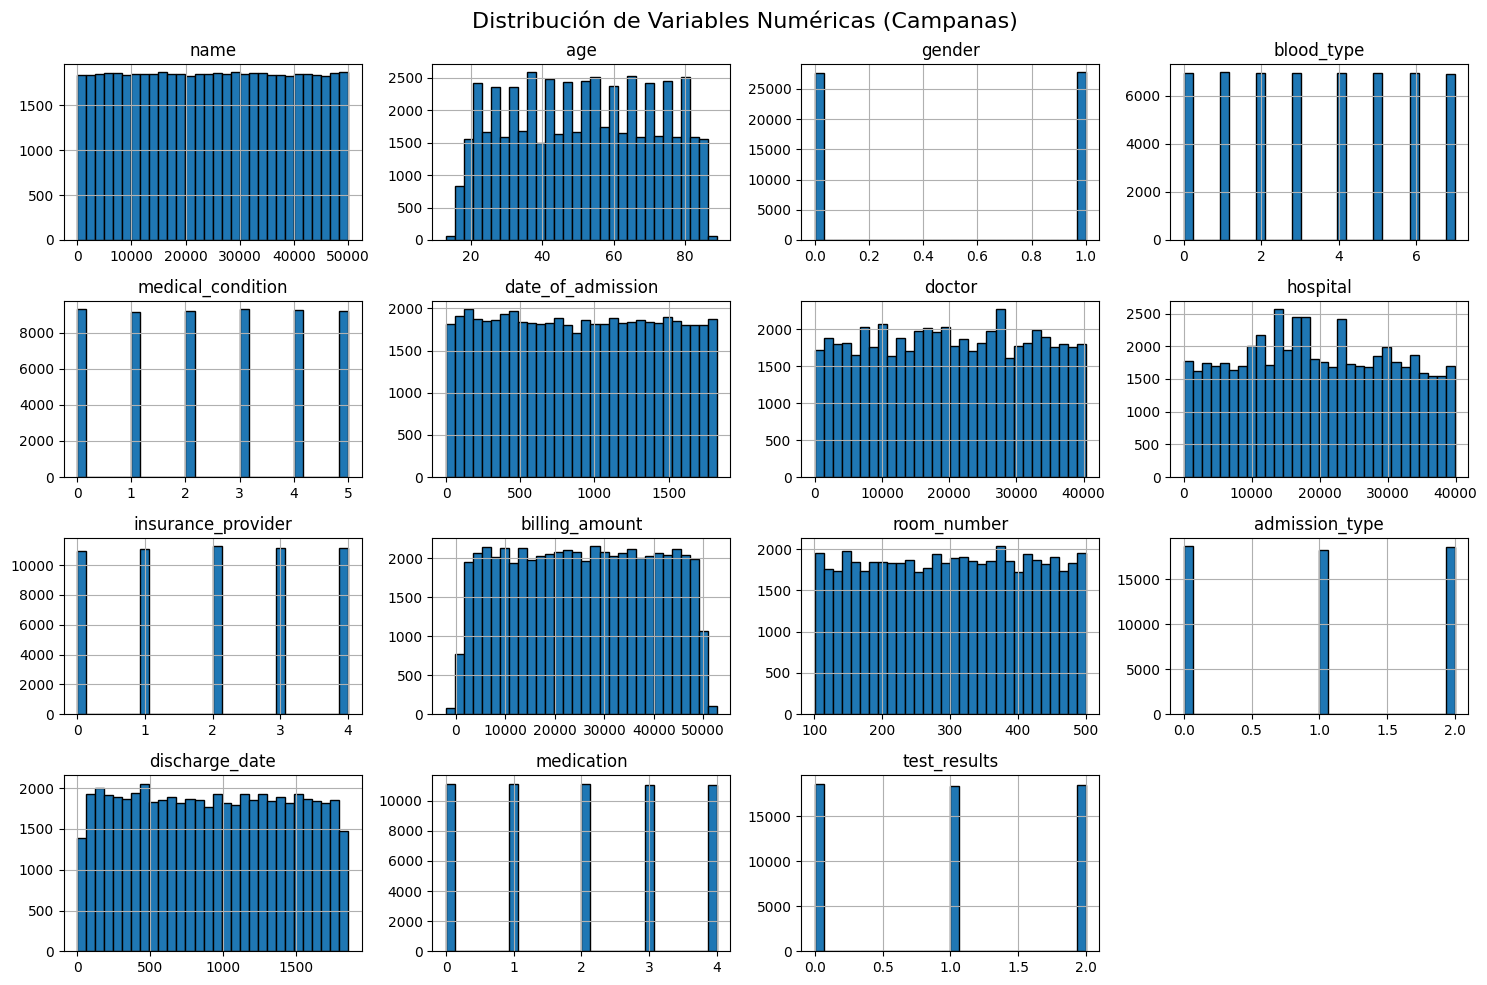

In [ ]:
import matplotlib.pyplot as plt

# Primero normalizamos nombres para evitar el KeyError
df_numerico.columns = df_numerico.columns.str.strip().str.lower().str.replace(' ', '_')

# Dibujamos histogramas de todas las columnas numéricas
df_numerico.hist(figsize=(15, 10), bins=30, edgecolor='black')
plt.suptitle('Distribución de Variables Numéricas (Campanas)', fontsize=16)
plt.tight_layout()
plt.show()

Observamos que no existen valores atipicos representativos o casi no estan presentes,

## Validaciones de fecha

Ahora validamos las fechas de admision con las de alta, asi para identificar si hay valores que no sean del tipo, lo admiti el dia jueves 10 y lo di de alta el dia martes 08, como ejemplo, por lo que una nueva variable "days_of_stay" vamos a crear

In [ ]:
# Aseguramos que las columnas sean tipo fecha (datetime)
df['date_of_admission'] = pd.to_datetime(df['date_of_admission'])
df['discharge_date'] = pd.to_datetime(df['discharge_date'])

# Calculamos la diferencia y extraemos solo el número de días
df['days_of_stay'] = (df['discharge_date'] - df['date_of_admission']).dt.days

# Revisamos los primeros resultados
print(df[['date_of_admission', 'discharge_date', 'days_of_stay']].head())

  date_of_admission discharge_date  days_of_stay
0        2024-01-31     2024-02-02             2
1        2019-08-20     2019-08-26             6
2        2022-09-22     2022-10-07            15
3        2020-11-18     2020-12-18            30
4        2022-09-19     2022-10-09            20


In [ ]:
df.describe()

,age,date_of_admission,billing_amount,room_number,discharge_date,days_of_stay
count,55500.000000,55500,55500.000000,55500.000000,55500,55500.000000
mean,51.539459,2021-11-01 01:02:22.443243008,25539.316097,301.134829,2021-11-16 13:15:20.821621504,15.509009
min,13.000000,2019-05-08 00:00:00,-2008.492140,101.000000,2019-05-09 00:00:00,1.000000
25%,35.000000,2020-07-28 00:00:00,13241.224652,202.000000,2020-08-12 00:00:00,8.000000
50%,52.000000,2021-11-01 00:00:00,25538.069376,302.000000,2021-11-17 00:00:00,15.000000
75%,68.000000,2023-02-03 00:00:00,37820.508436,401.000000,2023-02-18 00:00:00,23.000000
max,89.000000,2024-05-07 00:00:00,52764.276736,500.000000,2024-06-06 00:00:00,30.000000
std,19.602454,NaN,14211.454431,115.243069,NaN,8.659600


In [ ]:
print(sorted(df["days_of_stay"].unique().tolist()))

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
